# SIOC 251: Radiative Transfer
## Homework 4: Two-Stream SW Radiative Transfer and the Aerosol Direct Radiative Effect

The atmosphere over the Arabian Sea contains both mineral aerosols advected primarily southward from the deserts of Afghanistan and Iran, and pollution aerosols emitted from South Asia.

**Goals:**
- Construct a spectrally resolved shortwave two-stream radiative transfer model
- Include aerosol and Rayleigh scattering layers
- Calculate spectral and broadband shortwave fluxes
- Estimate the TOA, surface, and atmospheric aerosol direct radiative effect
- Compare the radiative effects of dust and pollution aerosols

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

## Section 5: Two-Stream Model Construction

In [26]:
def r_inf(omega, g):
    return (xr.ufuncs.sqrt(1 - omega * g) - xr.ufuncs.sqrt(1 - omega)) / (xr.ufuncs.sqrt(1 - omega * g) + xr.ufuncs.sqrt(1 - omega))

def gamma(omega, g):
    return 2 * xr.ufuncs.sqrt(1 - omega * g) * xr.ufuncs.sqrt(1 - omega)

def layer_reflectance(r_inf, gamma, tau):
    return r_inf * (xr.ufuncs.exp(gamma*tau) - xr.ufuncs.exp(-gamma*tau)) / (xr.ufuncs.exp(gamma*tau) - r_inf**2 * xr.ufuncs.exp(-gamma*tau))

def layer_transmittance(r_inf, gamma, tau):
    return (1 - r_inf**2) / (xr.ufuncs.exp(gamma*tau) - r_inf**2 * xr.ufuncs.exp(-gamma*tau))

def scene_reflectance(r_top, t_top, r_bot):
    return r_top + t_top**2 * r_bot / (1 - r_top * r_bot)

def scene_transmittance(r_top, t_top, r_bot):
    return t_top / (1 - r_top * r_bot)

def two_stream_model(ds_atm, ds_sfc):
    ds_atm['r_inf'] = r_inf(omega=ds_atm['omega'], g=ds_atm['g'])
    ds_atm['gamma'] = gamma(omega=ds_atm['omega'], g=ds_atm['g'])
    ds_atm['reflectance'] = layer_reflectance(r_inf=ds_atm['r_inf'], gamma=ds_atm['gamma'], tau=ds_atm['tau'])
    ds_atm['transmittance'] = layer_transmittance(r_inf=ds_atm['r_inf'], gamma=ds_atm['gamma'], tau=ds_atm['tau'])

    r = ds_atm.isel(atm_layer=0)['reflectance']
    t = ds_atm.isel(atm_layer=0)['transmittance']

    r_scenes = [r]
    t_scenes = [t]

    for i in range(len(ds_atm['atm_layer']) - 1):
        bot_layer = ds_atm.isel(atm_layer=i + 1)
        r_new = scene_reflectance(r_top=r, t_top=t, r_bot=bot_layer['reflectance'])
        t_new = bot_layer['transmittance'] * scene_transmittance(r_top=r, t_top=t, r_bot=bot_layer['reflectance'])
        r, t = r_new, t_new
        r_scenes.append(r)
        t_scenes.append(t)

    r_sfc = scene_reflectance(r_top=r, t_top=t, r_bot=ds_sfc['reflectance'])
    t_sfc = scene_transmittance(r_top=r, t_top=t, r_bot=ds_sfc['reflectance'])
    r_scenes.append(r_sfc)
    t_scenes.append(t_sfc)

    return xr.Dataset(
        data_vars=dict(
            reflectance=(['scene_idx', 'lambda_mu'], np.stack([s.values for s in r_scenes])),
            transmittance=(['scene_idx', 'lambda_mu'], np.stack([s.values for s in t_scenes])),
        ),
        coords=dict(
            lambda_mu=ds_atm.lambda_mu.values,
            scene_idx=np.arange(len(r_scenes)),
        )
    )

In [27]:
df_aer = pd.read_csv('data/aerosol_properties.csv')
df_or = pd.read_csv('data/ocean_reflectance.csv')
ds_ocean = df_or.rename(columns={'lambda (mu)':'lambda_mu'}).set_index('lambda_mu').to_xarray()

# Define rayleight scattering layer (clear sky)

# optical depth at 550 nm = 0.1, scale this optical depth to all model wavelengths
# tau = 0.1 * (550 nm / wavelength)^4

# single scatter albedo ~1, set to 0.99 to avoid divide by zero in r_inf
# g = 0, isotropic scattering

dl = 0.1
wavelength = np.round(np.arange(0.4, 4 + dl, dl), 1)

tau_r_55 = 0.1
tau_wave = tau_r_55 * (0.55 / wavelength)**4

ds_ray = xr.Dataset(
    data_vars=dict(
        tau=(["lambda_mu"], tau_wave),
        omega=(["lambda_mu"], (np.ones(len(wavelength)))*0.99),
        g=(["lambda_mu"], np.zeros(len(wavelength))),
    ),
    coords=dict(
        lambda_mu=wavelength,
    ),
)

# aerosol layer properties given (omega, g, and Be)
# calculate tau based on Be:
    # tau = integral(Be) dz
    # Be = d tau / dz
    # Be = tau_star / dz
    # dz = tau_star / Be <-- solve for dz from given tau_star = 1 for 550 nm
    # tau = Be * dz

df_dust = df_aer[['lambda (mu)','dust Be','dust g','dust omega']].rename(columns={'lambda (mu)':'lambda_mu','dust Be':'Be','dust g':'g','dust omega':'omega'})
df_poll = df_aer[['lambda (mu)','pollution Be','pollution g','pollution omega']].rename(columns={'lambda (mu)':'lambda_mu','pollution Be':'Be','pollution g':'g','pollution omega':'omega'})

ds_aer = xr.concat([
    df_dust.set_index('lambda_mu').to_xarray().expand_dims(aerosol=['dust']),
    df_poll.set_index('lambda_mu').to_xarray().expand_dims(aerosol=['pollution'])
],dim='aerosol')

ds_aer['tau'] = (1 / ds_aer['Be'].sel(lambda_mu = slice(0.5,0.6)).mean(dim='lambda_mu'))*ds_aer['Be']


poll_atm_ds = xr.concat([
    ds_aer[['tau','omega','g']].sel(aerosol='pollution').expand_dims(dim={"atm_layer": ['pollution']}).drop_vars('aerosol'),
    ds_ray[['tau','omega','g']].expand_dims(dim={"atm_layer": ['rayleigh']}),
],dim='atm_layer')

dust_atm_ds = xr.concat([
    ds_aer[['tau','omega','g']].sel(aerosol='dust').expand_dims(dim={"atm_layer": ['dust']}).drop_vars('aerosol'),
    ds_ray[['tau','omega','g']].expand_dims(dim={"atm_layer": ['rayleigh']}),
],dim='atm_layer')

### 5.2 — Verification

#### Test case 1
Make layer with infinetly thick cloud. The transmission of the scene should be 0. Adding layers above/below the cloud will not change the scene transmission and reflectance.
- cloud g = 0.8 (clouds are strongly forward scattering)
- cloud omega = 0.99 (all scattering, no absorption)
- cloud tau = 100
- test only cloud, rayleigh over cloud, and cloud over rayleigh
- fully absorbing surface

Results:

The scene reflection is not 1 because the single scatter albedo is not exactly one. So a cloud optical depth of 1,000 will have some absorption and reduce the overall reflection. The model confirms that the scene transmission can be numerically rounded to zero for all three cases (1e-40). There is some interesting behavior at the shorter wavelengths, which relates to the rayleigh scattering layer I added. The scene reflectance is higher for shorter wavelengths when the cloud is below the rayleigh layer because the shorter (blue) wavelengths scatter light isotropically, so some will be backscattered out, increasing the overall reflectance. Both transmittance cloud/rayleigh scenes decrease for shorter wavelengths, which confirms the behavior of the two stream model that scene transmission does not care about layer order, but scene reflection does. 

#### Test case 2
Scene transmission as a function of surface reflection. When the surface reflection is 1, the scene transmission will be zero. When the surface reflection is zero, the scene transmission will be 1 (if the atmosphere is transparent).
- use rayleigh scattering layer
- test five surface reflection values [0, 0.25, 0.5, 0.75, 1]

Results:

The scene reflection scales 1:1 with the surface reflection for longer wavelengths. The shorter wavelengths show the effects of rayleigh scattering. For each case the scene transmission is 1 because the atmosphere is transparent, so all radiation will pass through to the surface. But the scene reflection scales as expected from zero to one with the surface reflection. 

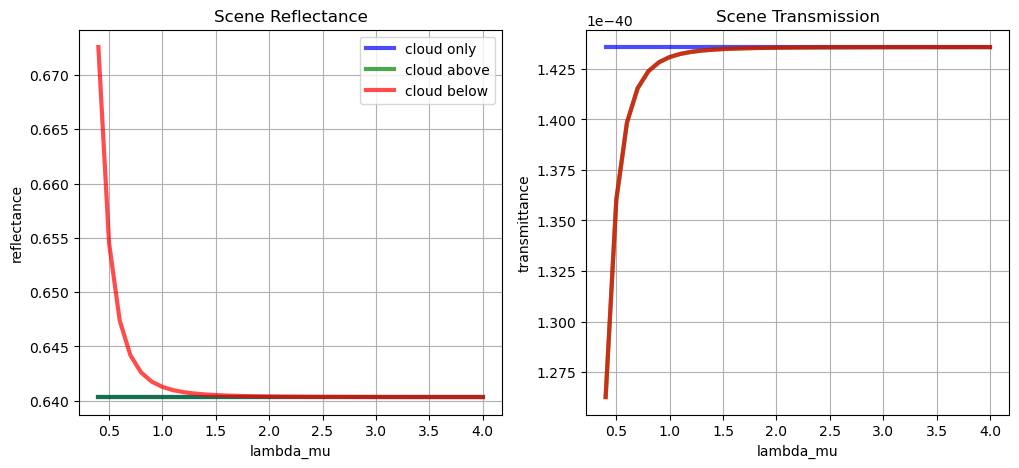

In [28]:
ds_cld_1 = xr.Dataset(
    data_vars=dict(
        tau=(["lambda_mu"], (np.ones(len(wavelength)))*1000),
        omega=(["lambda_mu"], (np.ones(len(wavelength)))*0.99),
        g=(["lambda_mu"], (np.ones(len(wavelength)))*0.8),
    ),
    coords=dict(
        lambda_mu=wavelength,
    ),
).expand_dims(dim={"atm_layer": ['cloud']})

ds_sfc = xr.Dataset(
    data_vars=dict(
        reflectance=(["lambda_mu"], (np.zeros(len(wavelength)))),
    ),
    coords=dict(
        lambda_mu=wavelength,
    ),
)

ds_cld_2 = xr.concat([
    ds_cld_1,
    ds_ray[['tau','omega','g']].expand_dims(dim={"atm_layer": ['rayleigh']}),
],dim='atm_layer')

ds_cld_3 = xr.concat([
    ds_ray[['tau','omega','g']].expand_dims(dim={"atm_layer": ['rayleigh']}),
    ds_cld_1,
],dim='atm_layer')

ds_1 = two_stream_model(ds_cld_1, ds_sfc)
ds_2 = two_stream_model(ds_cld_2, ds_sfc)
ds_3 = two_stream_model(ds_cld_3, ds_sfc)

r_1 = ds_1['reflectance'].isel(scene_idx=-1)
t_1 = ds_1['transmittance'].isel(scene_idx=-1)
r_2 = ds_2['reflectance'].isel(scene_idx=-1)
t_2 = ds_2['transmittance'].isel(scene_idx=-1)
r_3 = ds_3['reflectance'].isel(scene_idx=-1)
t_3 = ds_3['transmittance'].isel(scene_idx=-1)

fig, ax = plt.subplots(1, 2, figsize = (12,5))

r_1.plot(ax=ax[0],color='blue',label='cloud only', linewidth = 3, alpha = 0.7)
r_2.plot(ax=ax[0],color='green',label='cloud above', linewidth = 3, alpha = 0.7)
r_3.plot(ax=ax[0],color='red',label='cloud below', linewidth = 3, alpha = 0.7)

ax[0].set_title('Scene Reflectance')

t_1.plot(ax=ax[1],color='blue',label='cloud only', linewidth = 3, alpha = 0.7)
t_2.plot(ax=ax[1],color='green',label='cloud above', linewidth = 3, alpha = 0.7)
t_3.plot(ax=ax[1],color='red',label='cloud below', linewidth = 3, alpha = 0.7)

ax[1].set_title('Scene Transmission')
ax[1].grid()
ax[0].grid()

ax[0].legend()
plt.savefig('figures/test1_cloud_rt.png', dpi=150, bbox_inches='tight')

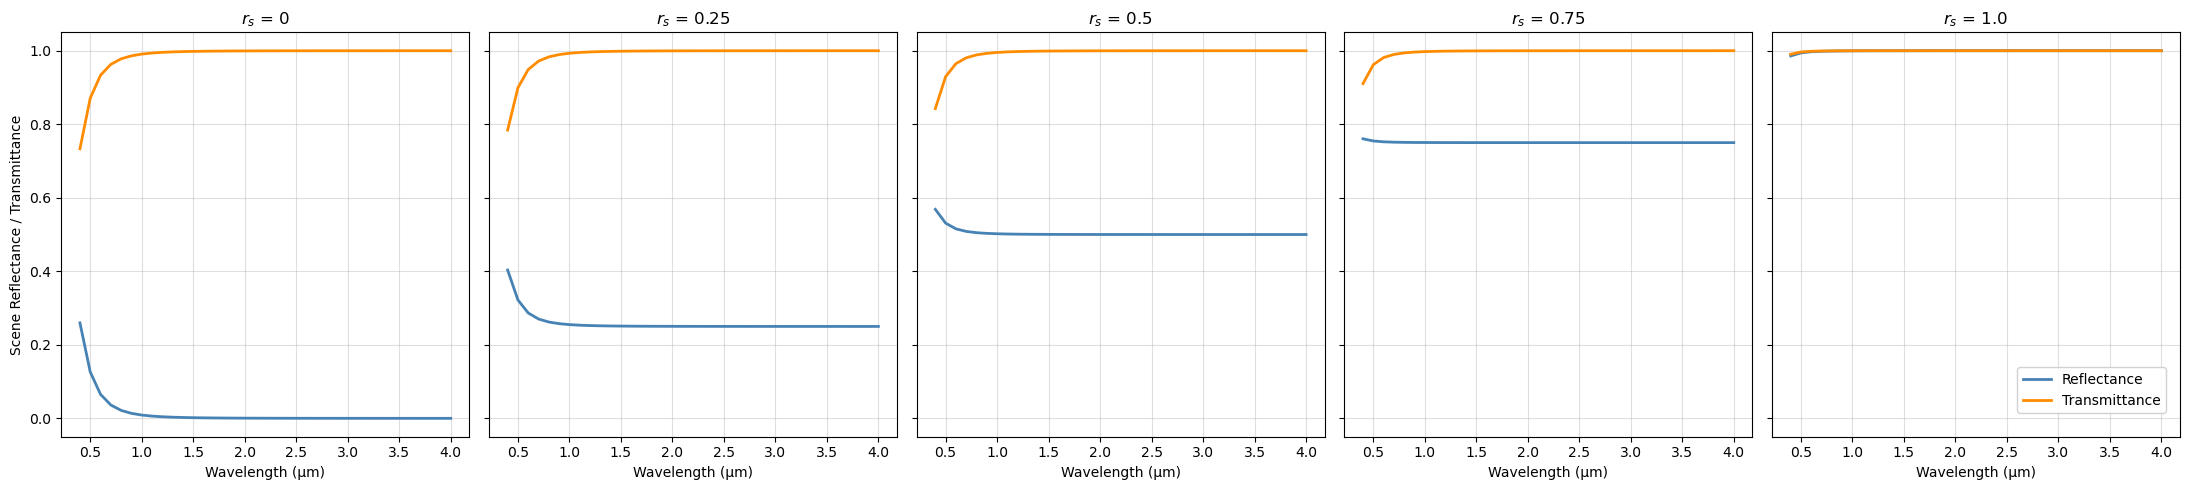

In [29]:
ds_sfc = xr.Dataset(
    data_vars=dict(
        reflectance=(["lambda_mu"], (np.ones(len(wavelength)))),
    ),
    coords=dict(
        lambda_mu=wavelength,
    ),
)

ray_ds = ds_ray[['tau','omega','g']].expand_dims(dim={"atm_layer": ['rayleigh']})

ds_0  = two_stream_model(ray_ds, ds_sfc * 0)
ds_25 = two_stream_model(ray_ds, ds_sfc * 0.25)
ds_5  = two_stream_model(ray_ds, ds_sfc * 0.5)
ds_75 = two_stream_model(ray_ds, ds_sfc * 0.75)
ds_1  = two_stream_model(ray_ds, ds_sfc)

r_0,  t_0  = ds_0['reflectance'].isel(scene_idx=-1),  ds_0['transmittance'].isel(scene_idx=-1)
r_25, t_25 = ds_25['reflectance'].isel(scene_idx=-1), ds_25['transmittance'].isel(scene_idx=-1)
r_5,  t_5  = ds_5['reflectance'].isel(scene_idx=-1),  ds_5['transmittance'].isel(scene_idx=-1)
r_75, t_75 = ds_75['reflectance'].isel(scene_idx=-1), ds_75['transmittance'].isel(scene_idx=-1)
r_1,  t_1  = ds_1['reflectance'].isel(scene_idx=-1),  ds_1['transmittance'].isel(scene_idx=-1)

fig, ax = plt.subplots(1, 5, figsize=(22, 5), sharey=True)

rs_vals = [0, 0.25, 0.5, 0.75, 1.0]
r_list  = [r_0, r_25, r_5, r_75, r_1]
t_list  = [t_0, t_25, t_5, t_75, t_1]

for i, (rs, r, t) in enumerate(zip(rs_vals, r_list, t_list)):
    l1, = ax[i].plot(r.lambda_mu, r.values, color='steelblue',  linewidth=2)
    l2, = ax[i].plot(t.lambda_mu, t.values, color='darkorange', linewidth=2)
    ax[i].set_title(f'$r_s$ = {rs}')
    ax[i].set_xlabel('Wavelength (μm)')
    ax[i].grid(alpha=0.4)

ax[0].set_ylabel('Scene Reflectance / Transmittance')

fig.legend([l1, l2], ['Reflectance', 'Transmittance'],
           loc='lower right', bbox_to_anchor=(0.99, 0.15), framealpha=0.9)
plt.tight_layout()
plt.savefig('figures/test2_surface_reflection.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 — Question

- For each aerosol type, calculate the spectrally resolved **transmittance** (at the surface) and **albedo** (at the TOA). Are these variables and their differences between the two aerosol types consistent with the aerosol single scatter properties?

Pollution is a more absorbing aerosol than dust, which means given the same optical depth, the albedo should be higher for dust. This is aparent for the shorter wavelengths, where dust and pollution have the same optical depth but the dust albedo is much higher. 

In [30]:
ds_poll = two_stream_model(ds_atm=poll_atm_ds, ds_sfc=ds_ocean)
ds_dust = two_stream_model(ds_atm=dust_atm_ds, ds_sfc=ds_ocean)

# r_poll = ds_poll['reflectance'].isel(scene_idx=-1)
# t_poll = ds_poll['transmittance'].isel(scene_idx=-1)
# r_dust = ds_dust['reflectance'].isel(scene_idx=-1)
# t_dust = ds_dust['transmittance'].isel(scene_idx=-1)

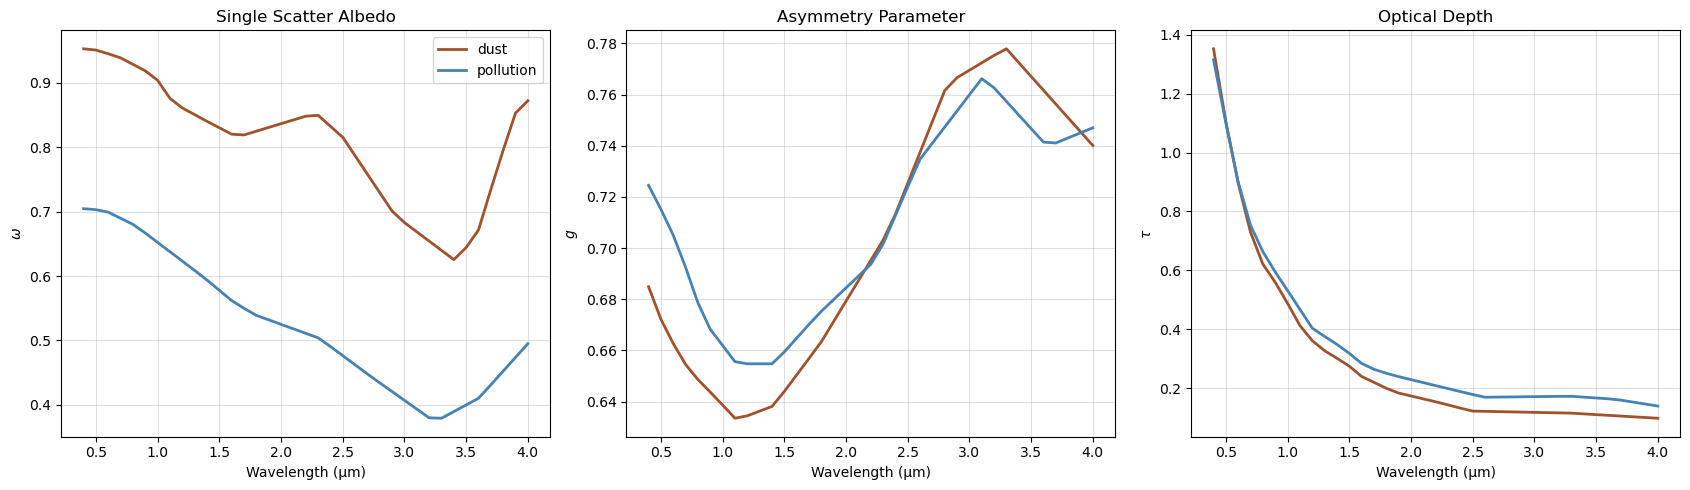

In [31]:
fig, ax = plt.subplots(1, 3, figsize=(17, 5))

for aer, color in [('dust', 'sienna'), ('pollution', 'steelblue')]:
    ax[0].plot(ds_aer.lambda_mu, ds_aer['omega'].sel(aerosol=aer), color=color, linewidth=2, label=aer)
    ax[1].plot(ds_aer.lambda_mu, ds_aer['g'].sel(aerosol=aer),     color=color, linewidth=2, label=aer)
    ax[2].plot(ds_aer.lambda_mu, ds_aer['tau'].sel(aerosol=aer),   color=color, linewidth=2, label=aer)

ax[0].set_title('Single Scatter Albedo')
ax[0].set_xlabel('Wavelength (μm)')
ax[0].set_ylabel('$\omega$')
ax[0].grid(alpha=0.4)

ax[1].set_title('Asymmetry Parameter')
ax[1].set_xlabel('Wavelength (μm)')
ax[1].set_ylabel('$g$')
ax[1].grid(alpha=0.4)

ax[2].set_title('Optical Depth')
ax[2].set_xlabel('Wavelength (μm)')
ax[2].set_ylabel('$\\tau$')
ax[2].grid(alpha=0.4)

ax[0].legend()
plt.tight_layout()
plt.savefig('figures/aer_single_scatter_properties.png', dpi=150, bbox_inches='tight')
plt.show()

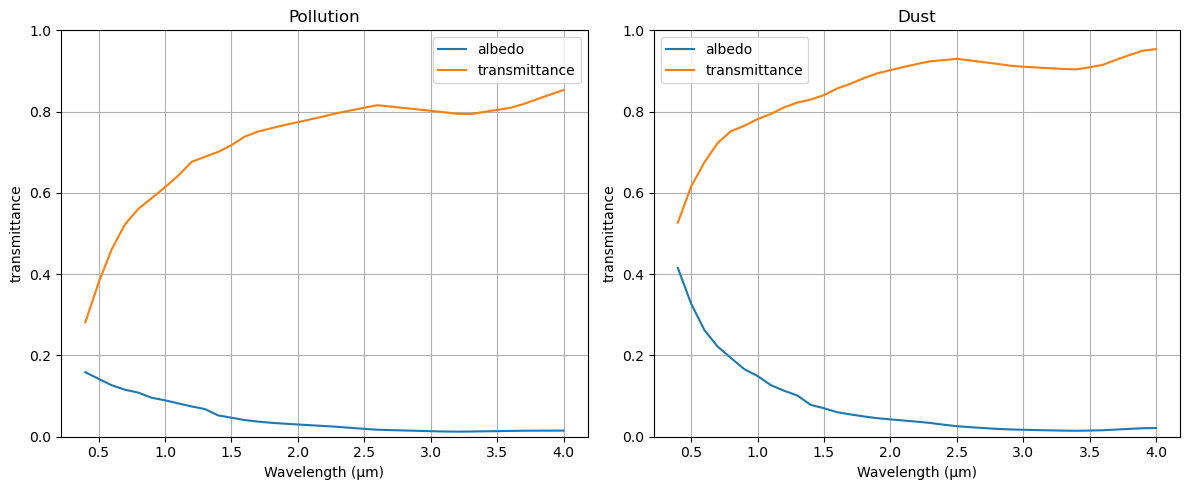

In [32]:
fig, ax = plt.subplots(1,2,figsize=(12,5))

ds_poll['reflectance'].isel(scene_idx=-1).plot(ax=ax[0], label='albedo')
ds_poll['transmittance'].isel(scene_idx=-1).plot(ax=ax[0], label='transmittance')
ax[0].set_title("Pollution")
ax[0].grid()
ax[0].legend()
ax[0].set_ylim(0,1)
ax[0].set_xlabel('Wavelength (μm)')

ds_dust['reflectance'].isel(scene_idx=-1).plot(ax=ax[1], label='albedo')
ds_dust['transmittance'].isel(scene_idx=-1).plot(ax=ax[1], label='transmittance')
ax[1].set_title("Dust")
ax[1].grid()
ax[1].legend()
ax[1].set_ylim(0,1)
ax[1].set_xlabel('Wavelength (μm)')

plt.tight_layout()
plt.savefig('figures/aer_reflectance_transmittance.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 6: Part II — Shortwave Fluxes and the DRE

### 6.1a — Read TOA Solar Flux

In [33]:
fo_df = pd.read_csv('data/Fo.csv')

# np.min(np.diff(fo_ds['lambda_mu'].data))
fo_df['lambda_mu'] = (fo_df['lambda (nm)'] / 1000).round(4)

fo_df['TOA_flux_w_m2_um'] = fo_df[' TOA Flux (W/m2/nm)'] * 1000
fo_ds = fo_df.set_index('lambda_mu')['TOA_flux_w_m2_um'].to_xarray()

### 6.1b — Compute Spectral and Broadband Fluxes

In [34]:
ds_clr = two_stream_model(ds_atm=ds_ray[['tau','omega','g']].expand_dims(dim={"atm_layer": ['rayleigh']}), ds_sfc=ds_ocean)

In [35]:
# fo_ds.sel(lambda_mu = r_poll['lambda_mu'], method = 'nearest')
# fo_ds.sel(lambda_mu = slice(r_poll['lambda_mu'].min(), r_poll['lambda_mu'].max()))

ds_ocean_interp = ds_ocean.interp_like(fo_ds,method='linear').fillna(0)

ds_clr_interp = ds_clr.interp_like(fo_ds,method='linear')
ds_clr_interp['reflectance'] = ds_clr_interp['reflectance'].fillna(0)
ds_clr_interp['transmittance'] = ds_clr_interp['transmittance'].fillna(1)

ds_poll_interp = ds_poll.interp_like(fo_ds,method='linear')
ds_poll_interp['reflectance'] = ds_poll_interp['reflectance'].fillna(0)
ds_poll_interp['transmittance'] = ds_poll_interp['transmittance'].fillna(1)

ds_dust_interp = ds_dust.interp_like(fo_ds,method='linear')
ds_dust_interp['reflectance'] = ds_dust_interp['reflectance'].fillna(0)
ds_dust_interp['transmittance'] = ds_dust_interp['transmittance'].fillna(1)

### 6.1c — Compute the DRE

In [36]:
def compute_dre(fo_ds, ds_clr, ds_aer, ds_sfc):
    """
    Compute spectrally resolved DRE from pre-interpolated model outputs.

    Inputs:
      fo_ds  — TOA solar flux DataArray (lambda_mu)
      ds_clr — clear-sky two_stream_model output (scene_idx x lambda_mu)
      ds_aer — aerosol two_stream_model output  (scene_idx x lambda_mu)
      ds_sfc — surface reflectance dataset       (lambda_mu)

    Returns xr.Dataset with lambda_mu and variables DRE_TOA, DRE_sfc, DRE_atm.
    """
    dre_toa = (ds_clr['reflectance'].isel(scene_idx=-1)   - ds_aer['reflectance'].isel(scene_idx=-1))   * fo_ds
    dre_sfc = (ds_aer['transmittance'].isel(scene_idx=-2) - ds_clr['transmittance'].isel(scene_idx=-2)) * (1 - ds_sfc['reflectance']) * fo_ds
    dre_atm = dre_toa - dre_sfc

    return xr.Dataset(
        data_vars={
            'DRE_TOA': ('lambda_mu', dre_toa.values),
            'DRE_sfc': ('lambda_mu', dre_sfc.values),
            'DRE_atm': ('lambda_mu', dre_atm.values),
        },
        coords={'lambda_mu': fo_ds.lambda_mu.values}
    )

In [37]:
dre_poll = compute_dre(fo_ds, ds_clr_interp, ds_poll_interp, ds_ocean_interp)
dre_dust = compute_dre(fo_ds, ds_clr_interp, ds_dust_interp, ds_ocean_interp)

# surface downwelling fluxes kept for verification plot
f_down_p    = fo_ds * ds_clr_interp['transmittance'].isel(scene_idx=-2)
f_down_poll = fo_ds * ds_poll_interp['transmittance'].isel(scene_idx=-2)
f_down_dust = fo_ds * ds_dust_interp['transmittance'].isel(scene_idx=-2)

### 6.2 — Verification

Plot transmitted solar flux at the surface for clear sky, polluted sky, and dust sky. The polluted and dust sky should have lower flux values from 0.4 to 4 um. The pollution should be lower than the dust.

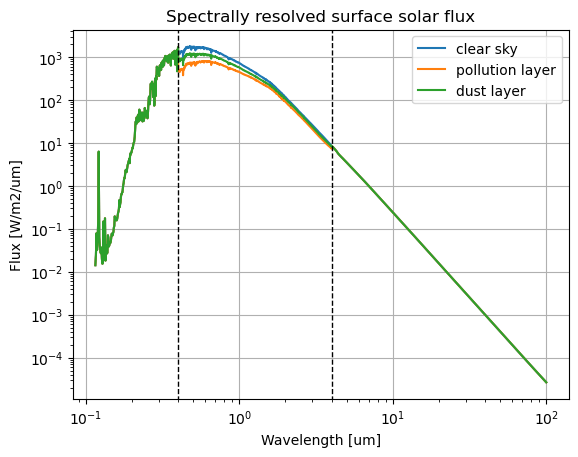

In [38]:
f_down_p.plot(label='clear sky')
f_down_poll.plot(label='pollution layer')
f_down_dust.plot(label='dust layer')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid()

plt.vlines([0.4,4],ymin=10e-6,ymax=10e4,color='k',linewidth=1,linestyle='dashed')
plt.title('Spectrally resolved surface solar flux')
plt.xlabel('Wavelength [um]')
plt.ylabel('Flux [W/m2/um]')
plt.savefig('figures/surface_solar_flux.png', dpi=150, bbox_inches='tight')

### 6.3 — Questions

- For $\tau_{a,0.55} = 1.0$, what is the instantaneous DRE at the top of the atmosphere for dust and pollution aerosols? What causes any differences between them?

Pollution has a much lower TOA DRE compared to dust. This is because the single scatter albedo of dust is higher. The single scatter albedo for dust is always greater than 0.5, meaning extinction events are more likely to be scattering. Pollution on the other hand favors absorption extinction events for longer wavelengths (omega < 0.5), and is more absorptive at all wavelengths. 

In [39]:
print(f"TOA Direct Radiative Effect -- Pollution -- : {dre_poll['DRE_TOA'].integrate(coord='lambda_mu').data.round(2)} W/m2")
print(f"TOA Direct Radiative Effect -- Dust      -- : {dre_dust['DRE_TOA'].integrate(coord='lambda_mu').data.round(2)} W/m2")
print(" ")
print(f"SFC Direct Radiative Effect -- Pollution -- : {dre_poll['DRE_sfc'].integrate(coord='lambda_mu').data.round(2)} W/m2")
print(f"SFC Direct Radiative Effect -- Dust      -- : {dre_dust['DRE_sfc'].integrate(coord='lambda_mu').data.round(2)} W/m2")
print(" ")
print(f"ATM Direct Radiative Effect -- Pollution -- : {dre_poll['DRE_atm'].integrate(coord='lambda_mu').data.round(2)} W/m2")
print(f"ATM Direct Radiative Effect -- Dust      -- : {dre_dust['DRE_atm'].integrate(coord='lambda_mu').data.round(2)} W/m2")

TOA Direct Radiative Effect -- Pollution -- : -3.18 W/m2
TOA Direct Radiative Effect -- Dust      -- : -130.25 W/m2
 
SFC Direct Radiative Effect -- Pollution -- : -464.02 W/m2
SFC Direct Radiative Effect -- Dust      -- : -255.52 W/m2
 
ATM Direct Radiative Effect -- Pollution -- : 460.84 W/m2
ATM Direct Radiative Effect -- Dust      -- : 125.27 W/m2


- Based on the sign of the TOA DRE, do these aerosols warm or cool the climate system?

Both aerosols have a cooling effect, but the dust aerosols have a much larger cooling effect. This is because the TOA DRE is negative, which means there is more outgoing SW radiation in the presence of aerosols than otherwise would be for pristine condtions. 

- How do you think the presence of these aerosols may influence convection?

Reducing the incoming SW radiation will likely reduce convection. Convection works to transport heat away from the surface, but if there is less solar heating then less convection is needed. Additionally, if the pollution aerosols absorb shortwave radiation in the atmosphere, it will cause some heating which will increase stratification and therefore stability, which reduces convective potential. 

- Do changes in surface reflectance have a similar effect on both types of aerosol species?

Changes in surface reflection have similar effects on surface and atmospheric DRE for both types of aerosols. But the top of atmosphere change is highly sensitive to the type of aerosol. When the surface is perfectly reflecting, it means all the radiation either has to be absorbed or scattered out the top of atmosphere. In the pollution case, the layer is more absorptive so the totally reflecting surface will change the TOA DRE significantly. In the dust case, more radiation is likely to be scattered out the top of atmosphere, which is the same in the clear sky case, so the effect on TOA DRE is not as dramatic. 

Surface          Aerosol         DRE_TOA      DRE_sfc      DRE_atm  (W/m²)
--------------------------------------------------------------------
black (r_s=0)    poll             -43.58      -494.97       451.39
black (r_s=0)    dust            -155.78      -272.57       116.79

ocean            poll              -3.18      -464.02       460.84
ocean            dust            -130.25      -255.52       125.27

white (r_s=1)    poll             699.29         0.00       699.29
white (r_s=1)    dust             218.33         0.00       218.33



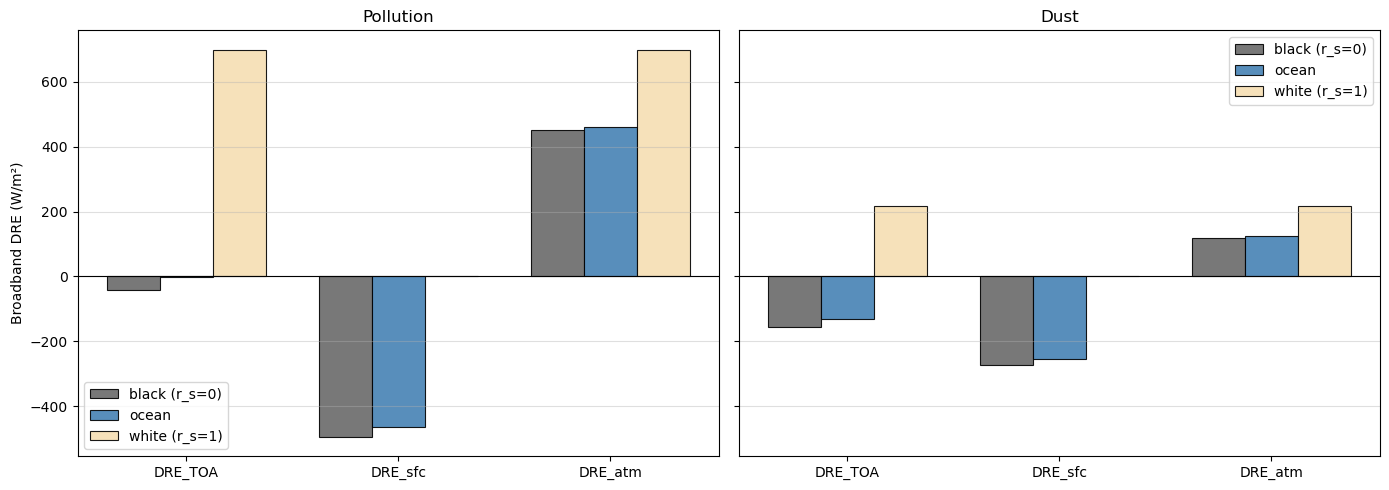

In [40]:
ds_sfc_black = xr.Dataset({'reflectance': ('lambda_mu', np.zeros(len(wavelength)))}, coords={'lambda_mu': wavelength})
ds_sfc_white = xr.Dataset({'reflectance': ('lambda_mu', np.ones(len(wavelength)))},  coords={'lambda_mu': wavelength})
ds_sfc_ocean = ds_ocean.interp(lambda_mu=wavelength, method='linear').fillna(0)

sfc_configs = {'black (r_s=0)': ds_sfc_black, 'ocean': ds_sfc_ocean, 'white (r_s=1)': ds_sfc_white}
ray_atm = ds_ray[['tau','omega','g']].expand_dims(dim={"atm_layer": ['rayleigh']})

def _interp_model(ds):
    ds_i = ds.interp_like(fo_ds, method='linear')
    ds_i['reflectance']   = ds_i['reflectance'].fillna(0)
    ds_i['transmittance'] = ds_i['transmittance'].fillna(1)
    return ds_i

sfc_dre = {}
for sfc_name, ds_sfc_i in sfc_configs.items():
    clr  = _interp_model(two_stream_model(ray_atm.copy(deep=True),     ds_sfc_i))
    poll = _interp_model(two_stream_model(poll_atm_ds.copy(deep=True), ds_sfc_i))
    dust = _interp_model(two_stream_model(dust_atm_ds.copy(deep=True), ds_sfc_i))
    sfc_interp = ds_sfc_i['reflectance'].interp_like(fo_ds, method='linear').fillna(0).to_dataset(name='reflectance')
    sfc_dre[sfc_name] = {
        'poll': compute_dre(fo_ds, clr, poll, sfc_interp),
        'dust': compute_dre(fo_ds, clr, dust, sfc_interp),
    }

# broadband summary table
dre_vars = ['DRE_TOA', 'DRE_sfc', 'DRE_atm']
print(f"{'Surface':<16} {'Aerosol':<10} {'DRE_TOA':>12} {'DRE_sfc':>12} {'DRE_atm':>12}  (W/m²)")
print('-' * 68)
for sfc_name, aer_dict in sfc_dre.items():
    for aer_name, dre_ds in aer_dict.items():
        vals = [float(dre_ds[v].integrate('lambda_mu')) for v in dre_vars]
        print(f"{sfc_name:<16} {aer_name:<10} {vals[0]:>12.2f} {vals[1]:>12.2f} {vals[2]:>12.2f}")
    print()

# bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
x      = np.arange(len(dre_vars))
width  = 0.25
colors = ['dimgray', 'steelblue', 'wheat']

for ax, aer_name, title in zip(axes, ['poll', 'dust'], ['Pollution', 'Dust']):
    for j, sfc_name in enumerate(sfc_configs):
        vals = [float(sfc_dre[sfc_name][aer_name][v].integrate('lambda_mu')) for v in dre_vars]
        ax.bar(x + j*width, vals, width, label=sfc_name, color=colors[j], edgecolor='k', linewidth=0.8, alpha=0.9)
    ax.set_xticks(x + width)
    ax.set_xticklabels(dre_vars)
    ax.set_title(title)
    ax.axhline(0, color='k', linewidth=0.8)
    ax.grid(axis='y', alpha=0.4)
    ax.legend()

axes[0].set_ylabel('Broadband DRE (W/m²)')
plt.tight_layout()
plt.savefig('figures/dre_surface_albedo.png', dpi=150, bbox_inches='tight')
plt.show()

In [41]:
ocean_ref = {aer: {v: float(sfc_dre['ocean'][aer][v].integrate('lambda_mu')) for v in dre_vars}
             for aer in ['poll', 'dust']}

print(f"{'Surface':<16} {'Aerosol':<10} {'DRE_TOA':>12} {'DRE_sfc':>12} {'DRE_atm':>12}  (normalized to ocean = 1)")
print('-' * 68)
for sfc_name, aer_dict in sfc_dre.items():
    for aer_name, dre_ds in aer_dict.items():
        vals = [float(dre_ds[v].integrate('lambda_mu')) / ocean_ref[aer_name][v] for v in dre_vars]
        print(f"{sfc_name:<16} {aer_name:<10} {vals[0]:>12.3f} {vals[1]:>12.3f} {vals[2]:>12.3f}")
    print()

Surface          Aerosol         DRE_TOA      DRE_sfc      DRE_atm  (normalized to ocean = 1)
--------------------------------------------------------------------
black (r_s=0)    poll             13.701        1.067        0.979
black (r_s=0)    dust              1.196        1.067        0.932

ocean            poll              1.000        1.000        1.000
ocean            dust              1.000        1.000        1.000

white (r_s=1)    poll           -219.867       -0.000        1.517
white (r_s=1)    dust             -1.676       -0.000        1.743



- Which aerosol species has a larger TOA forcing efficiency and why?

Dust has a much larger TOA forcing efficiency, -123 W/m2/tau_550 vs -21 W/m2/tau_550 for pollution. This is because at higher optical depths, the dust will scatter more light out TOA, increasing the forcing efficiency. Pollution focing efficiency goes to zero for larger optical depths because most of the light is being absorbed and therefore increasing optical depth no longer changes TOA DRE much. 

In [42]:
# sweep tau_055 by scaling the aerosol optical depth spectrum
tau_scales = np.array([0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0])

fe_data = {}
for aer_name, atm_ds in [('dust', dust_atm_ds), ('poll', poll_atm_ds)]:
    dre_bb = []
    for alpha in tau_scales:
        atm_scaled = atm_ds.copy(deep=True)
        atm_scaled['tau'] = atm_scaled['tau'] * alpha
        ds_model = _interp_model(two_stream_model(atm_scaled, ds_ocean))
        dre = compute_dre(fo_ds, ds_clr_interp, ds_model, ds_ocean_interp)
        dre_bb.append(float(dre['DRE_TOA'].integrate('lambda_mu')))
    fe_data[aer_name] = xr.DataArray(dre_bb, coords={'tau_055': tau_scales}, dims='tau_055')

# FE = dDRE_bb/dtau_055 evaluated at tau_055 = 1 via central differences
idx1 = np.where(tau_scales == 1.0)[0][0]
fe_dust = np.gradient(fe_data['dust'].values, tau_scales)[idx1]
fe_poll = np.gradient(fe_data['poll'].values, tau_scales)[idx1]

print(f"Forcing Efficiency -- Dust:      {fe_dust:.2f} W/m² per unit τ₀.₅₅")
print(f"Forcing Efficiency -- Pollution: {fe_poll:.2f} W/m² per unit τ₀.₅₅")

Forcing Efficiency -- Dust:      -123.04 W/m² per unit τ₀.₅₅
Forcing Efficiency -- Pollution: -21.25 W/m² per unit τ₀.₅₅


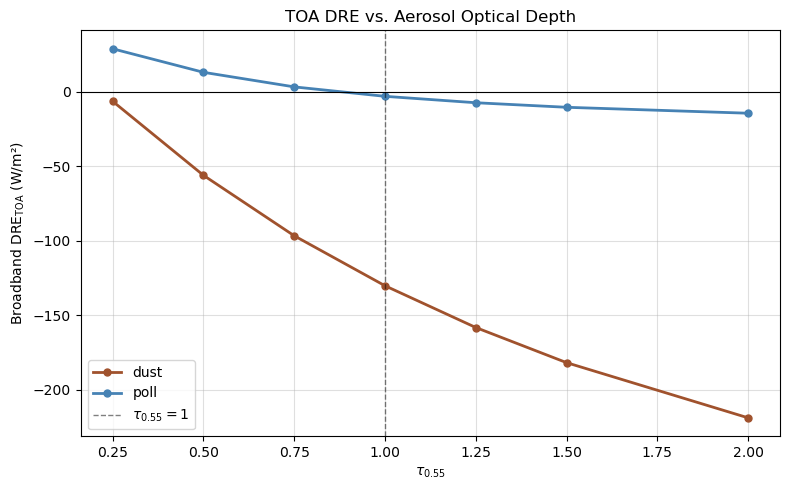

In [43]:
fig, ax = plt.subplots(figsize=(8, 5))

for aer_name, color in [('dust', 'sienna'), ('poll', 'steelblue')]:
    fe_data[aer_name].plot(ax=ax, label=aer_name, color=color, linewidth=2, marker='o', markersize=5)

ax.set_xlabel('$\\tau_{0.55}$')
ax.set_ylabel('Broadband DRE$_{\\mathrm{TOA}}$ (W/m²)')
ax.set_title('TOA DRE vs. Aerosol Optical Depth')
ax.axhline(0, color='k', linewidth=0.8)
ax.axvline(1.0, color='k', linewidth=1, linestyle='--', alpha=0.5, label='$\\tau_{0.55}=1$')
ax.legend()
ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig('figures/toa_dre_vs_tau.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 7: Part III — Student Investigation

**Question:** Where is the sw cre most effective at cooling the planet?

To do this I will model an atmosphere with three layers (rayleigh scattering, cloud, rayleigh scattering) above a surface with varying reflectivity. 

- liquid cloud properties (homework 3)
    - omega: 0.99
    - g: 0.8
    - tau: 10
    - cloud top height: 2 km
- clear sky properties
    - omega: 0.99
    - g: 0
    - tau (top): 0.08 at 550 nm <-- calculated using exponential decay of optical depth
    - tau (bottom): 0.1 at 550 nm

- Spectrally resolved surface reflection properties of different medium from [Humbolt State University geospatial lessons](https://gsp.humboldt.edu/olm/Courses/GSP_216/lessons/reflectance.html).
    - Grass
    - Conifer
    - Decidious
    - Snow
    - Soil
    - Water
    - Concrete

**Hypothesis:** The SW CRE will be most effective over dark/non reflective surfafces. For the tested surfaces, I expect this to be concrete, water and soil.

**Results:** When considering the TOA direct radiative effect, a cloud will have the most cooling potential over bodies of water, and then over vegetated areas. The cloud radiative effect being strongest over water confirms part of my hypothesis, but I was surprised by vegetation having stronger SWCRE than soil and concrete. Looking at the spectral reflectance, we can see that soil and concrete are more consistently reflective, even though the vegetated surfaces have a strong reflective peak from 0.75 um to 1.4 um. Since peak solar emission occurs around 0.5 um, the vegetative surfaces have the potential to absorb more SW radiation in clear sky conditions, and therefore have a stronger SWCRE. 

Snow is the only surface with a positive TOA SWCRE. My expectation was that the cloud would add to the reflectivity of the scene, increasing the overall albedo. But when the surface is already highly reflective in the peak of the visible light range, the cloud adds an absorptive feature to the scene and decreasing the amount of outgoing SW radiation. Snow is much less reflective at the longer wavelengths (near IR) but the solar flux for those wavelengths is less significant. 

I was quite surprised that concrete had the lowest TOA SWCRE. I expected concrete to act like a black body, but the reflectivity was substantial at all wavelengths. I think this has interesting implications for cities, which i am assuming can be approximated as a concrete surface. Cities should have higher aerosol concentrations and perhaps this could increase the SWCRE. An interesting next step to this question would be to compare the SWCRE values I calculated with observational data. From that analysis I may be able to infer something about the aerosol properties and cloud droplet size.

In [44]:
# load surface reflectances (values are percent → convert to fraction)
df_reflect = (pd.read_csv('data/reflect.csv')
              .rename(columns={'wavelength': 'lambda_mu'})
              .set_index('lambda_mu')
              .sort_index())
df_reflect = df_reflect / 100
ds_reflect = df_reflect.to_xarray()
surface_names = list(df_reflect.columns)

# build atmosphere layers
ds_ray_top = xr.Dataset(
    data_vars=dict(
        tau  =('lambda_mu', 0.08 * (0.55 / wavelength)**4),
        omega=('lambda_mu', np.ones(len(wavelength)) * 0.99),
        g    =('lambda_mu', np.zeros(len(wavelength))),
    ),
    coords={'lambda_mu': wavelength},
)

ds_cloud_layer = xr.Dataset(
    data_vars=dict(
        tau  =('lambda_mu', np.ones(len(wavelength)) * 10.0),
        omega=('lambda_mu', np.ones(len(wavelength)) * 0.99),
        g    =('lambda_mu', np.ones(len(wavelength)) * 0.8),
    ),
    coords={'lambda_mu': wavelength},
)

ds_ray_bot = xr.Dataset(
    data_vars=dict(
        tau  =('lambda_mu', 0.10 * (0.55 / wavelength)**4),
        omega=('lambda_mu', np.ones(len(wavelength)) * 0.99),
        g    =('lambda_mu', np.zeros(len(wavelength))),
    ),
    coords={'lambda_mu': wavelength},
)

cloud_atm_ds = xr.concat([
    ds_ray_top.expand_dims(dim={"atm_layer": ['rayleigh_top']}),
    ds_cloud_layer.expand_dims(dim={"atm_layer": ['cloud']}),
    ds_ray_bot.expand_dims(dim={"atm_layer": ['rayleigh_bot']}),
], dim='atm_layer')

clr_atm_ds = ds_ray[['tau','omega','g']].expand_dims(dim={"atm_layer": ['rayleigh']})

# run two-stream model for each surface (cloudy and clear sky)
ds_cld_scenes = {}
ds_clr_scenes = {}

for sfc_name in surface_names:
    sfc_ds = (ds_reflect[[sfc_name]]
              .rename({sfc_name: 'reflectance'})
              .interp(lambda_mu=wavelength, method='linear')
              .fillna(0))
    ds_cld_scenes[sfc_name] = two_stream_model(cloud_atm_ds.copy(deep=True), sfc_ds)
    ds_clr_scenes[sfc_name] = two_stream_model(clr_atm_ds.copy(deep=True),   sfc_ds)

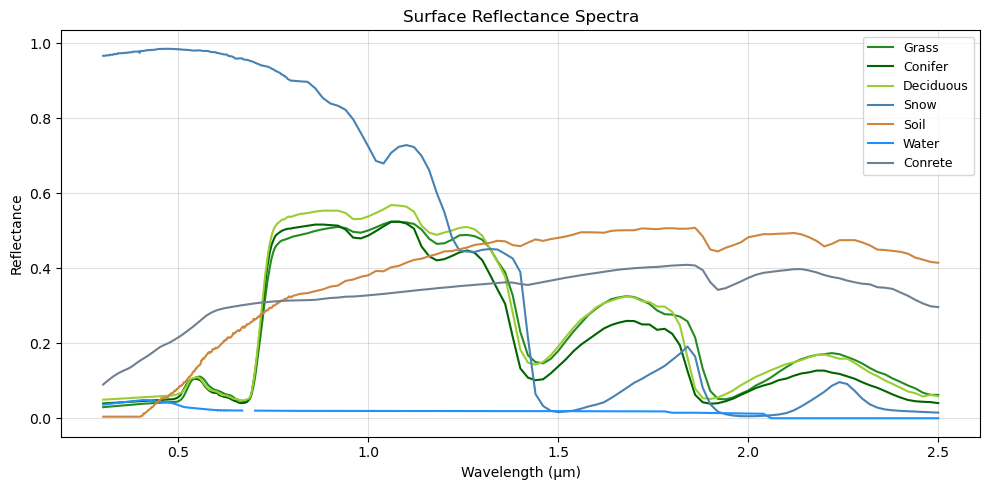

In [45]:
sfc_colors = {
    'Grass': 'forestgreen', 'Conifer': 'darkgreen', 'Deciduous': 'yellowgreen',
    'Snow': 'steelblue', 'Soil': 'peru', 'Water': 'dodgerblue', 'Conrete': 'slategray'
}

fig, ax = plt.subplots(figsize=(10, 5))
for sfc_name in surface_names:
    ax.plot(ds_reflect.lambda_mu, ds_reflect[sfc_name],
            label=sfc_name, color=sfc_colors[sfc_name], linewidth=1.5)

ax.set_xlabel('Wavelength (μm)')
ax.set_ylabel('Reflectance')
ax.set_title('Surface Reflectance Spectra')
ax.legend(fontsize=9)
ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig('figures/surface_reflectance_spectra.png', dpi=150, bbox_inches='tight')
plt.show()

In [46]:
# compute CRE for each surface (clear sky = pristine, cloudy = aerosol analogue)
sfc_colors = {
    'Grass': 'forestgreen', 'Conifer': 'darkgreen', 'Deciduous': 'yellowgreen',
    'Snow': 'steelblue', 'Soil': 'peru', 'Water': 'dodgerblue', 'Conrete': 'slategray'
}

cre_results = {}
for sfc_name in surface_names:
    clr_i = _interp_model(ds_clr_scenes[sfc_name])
    cld_i = _interp_model(ds_cld_scenes[sfc_name])
    sfc_i = (ds_reflect[[sfc_name]]
             .rename({sfc_name: 'reflectance'})
             .interp_like(fo_ds, method='linear')
             .fillna(0))
    cre_results[sfc_name] = compute_dre(fo_ds, clr_i, cld_i, sfc_i)

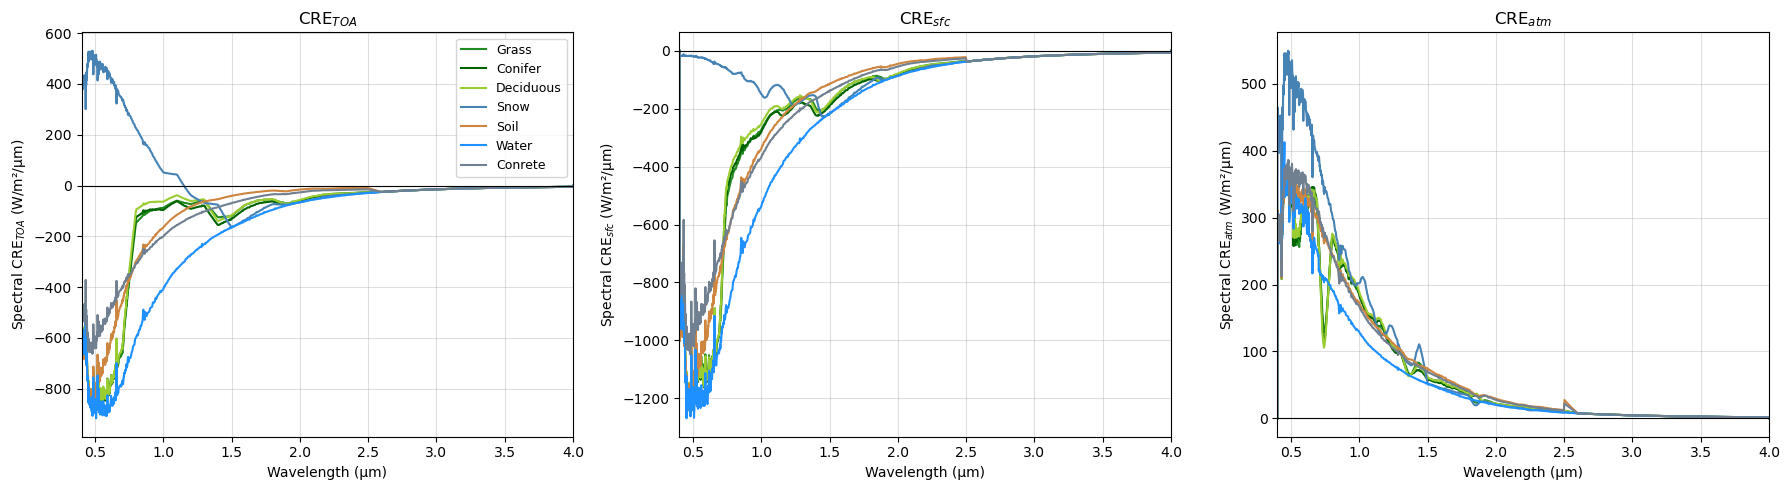

In [47]:
# --- spectral CRE plots (TOA, sfc, atm) ---
cre_labels = {'DRE_TOA': 'CRE$_{TOA}$', 'DRE_sfc': 'CRE$_{sfc}$', 'DRE_atm': 'CRE$_{atm}$'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
for ax, (var, label) in zip(axes, cre_labels.items()):
    for sfc_name in surface_names:
        cre = cre_results[sfc_name]
        ax.plot(cre.lambda_mu, cre[var],
                label=sfc_name, color=sfc_colors[sfc_name], linewidth=1.5)
    ax.set_xlim(0.4, 4.0)
    ax.axhline(0, color='k', linewidth=0.8)
    ax.set_xlabel('Wavelength (μm)')
    ax.set_ylabel(f'Spectral {label} (W/m²/μm)')
    ax.set_title(label)
    ax.grid(alpha=0.4)

axes[0].legend(fontsize=9)
plt.tight_layout()
plt.savefig('figures/cre_spectral.png', dpi=150, bbox_inches='tight')
plt.show()

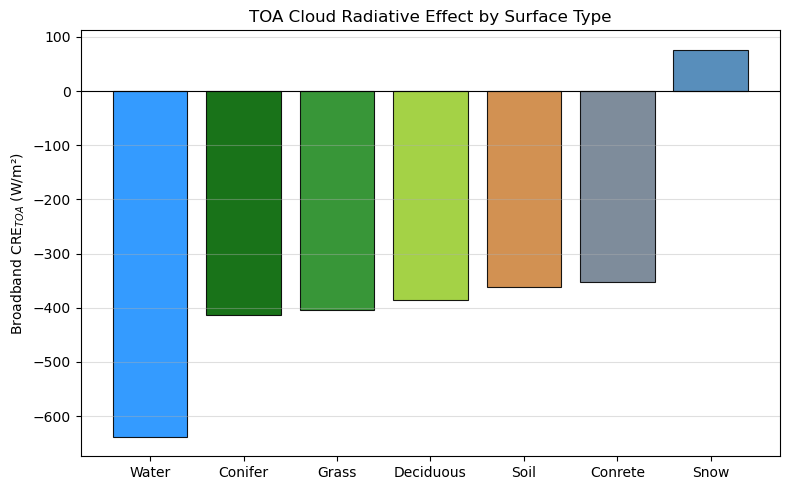

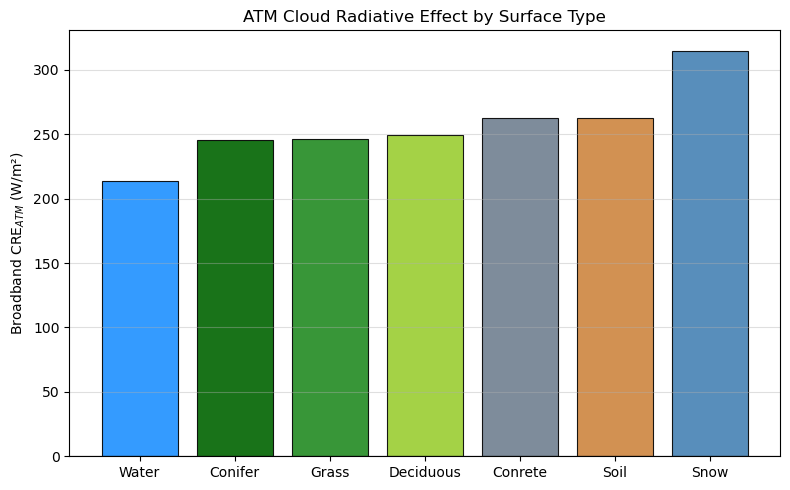

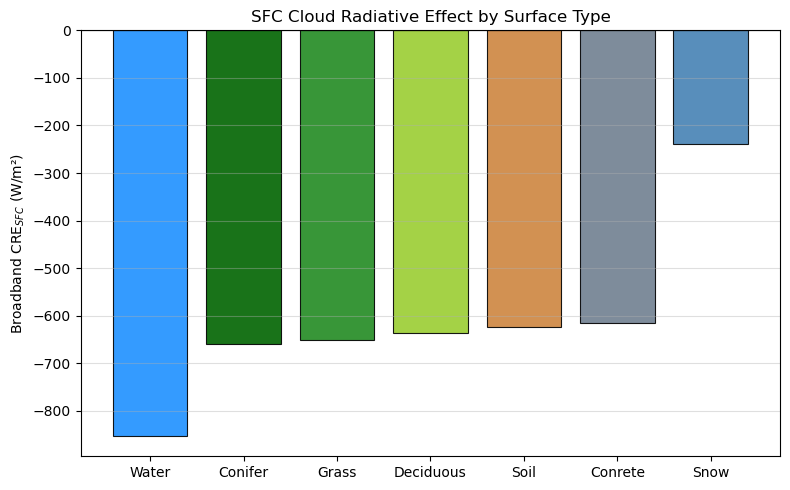

In [48]:
# --- broadband TOA CRE bar chart ---
cre_bb = {sfc: float(cre_results[sfc]['DRE_TOA'].integrate('lambda_mu'))
          for sfc in surface_names}
sfc_sorted = sorted(cre_bb, key=lambda s: cre_bb[s])

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(sfc_sorted, [cre_bb[s] for s in sfc_sorted],
       color=[sfc_colors[s] for s in sfc_sorted], edgecolor='k', linewidth=0.8, alpha=0.9)
ax.axhline(0, color='k', linewidth=0.8)
ax.set_ylabel('Broadband CRE$_{TOA}$ (W/m²)')
ax.set_title('TOA Cloud Radiative Effect by Surface Type')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('figures/cre_toa_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# --- broadband ATM CRE bar chart ---
cre_bb = {sfc: float(cre_results[sfc]['DRE_atm'].integrate('lambda_mu'))
          for sfc in surface_names}
sfc_sorted = sorted(cre_bb, key=lambda s: cre_bb[s])

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(sfc_sorted, [cre_bb[s] for s in sfc_sorted],
       color=[sfc_colors[s] for s in sfc_sorted], edgecolor='k', linewidth=0.8, alpha=0.9)
ax.axhline(0, color='k', linewidth=0.8)
ax.set_ylabel('Broadband CRE$_{ATM}$ (W/m²)')
ax.set_title('ATM Cloud Radiative Effect by Surface Type')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('figures/cre_atm_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# --- broadband SFC CRE bar chart ---
cre_bb = {sfc: float(cre_results[sfc]['DRE_sfc'].integrate('lambda_mu'))
          for sfc in surface_names}
sfc_sorted = sorted(cre_bb, key=lambda s: cre_bb[s])

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(sfc_sorted, [cre_bb[s] for s in sfc_sorted],
       color=[sfc_colors[s] for s in sfc_sorted], edgecolor='k', linewidth=0.8, alpha=0.9)
ax.axhline(0, color='k', linewidth=0.8)
ax.set_ylabel('Broadband CRE$_{SFC}$ (W/m²)')
ax.set_title('SFC Cloud Radiative Effect by Surface Type')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('figures/cre_sfc_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## AI Use Statement

*(Required — include at the end of your notebook)*

- **AI tools used:** Claude code
- **How I used them:**
    - "verify that i have correctly constructed the rayleigh and aerosol layers for the model"
    - "verify that i have correctly implemented the two stream reflectance and transmittance functions"
    - "finish the plot for test case 2 with each surface reflection in a seperate subplot. label each plot with the surface refleciton value and add axis labels. the subplots can share a yaxis label and use one legend for all plots"
    - "for question 5.3 make a plot with two subplots of the aerosol single scatter properties. one plot of omega and one of g. each plot should have pollution and dust plotted"
        - "add optical depth as a subplot"
    - "modify my two_stream_model so that it returns an xarray dataset with reflection and transmission from each "scene", which is the cumulative combination of the layers. I want the dimensions to be lambda_mu and scene_idx and the variable to be reflectance and transmittance. the function should now return one dataset"
        - "update calls of two_stream_model to use the new output structure"
    - "turn the code that calculates the different DRE into a function that returns a dataset with lambda_mu as a dimension and each DRE type (sfc, toa, and atm) as data variables. the inputs should be the fo_ds, ds_clr and ds_aer"
    - "test each aerosol DRE with totally absorbing sfc, totally reflecting sfc, and provided surface reflection"
    - "have i correctly calculated the forcing efficiency?"
        - highlighted two bugs -- one syntax and one theoretical. 
    - "For my student investigation, construct the atmosphere based on the provided cloud and sky properties. Run this through the two stream model with each surface reflection type which are saved in data/reflect.csv. don't create any plots yet"
        - I modified the construction of the clear sky atmosphere. The rest of the calculations looked good.
    - "calculate the cloud radiative effect for each surface type and create plots showing the spectrally resolved cloud radiative effect for all surface types and a bar chart with the TOA integrated cloud radiative effect"
        - added bar charts for the surface and atmosphere CRE
    - "make a plot of the reflectivity of each surface for context"
    - "check spelling and grammar in all the markdown cells in two_stream_aerosol_DRE.ipynb. fix any errors but don't change the language of the text"
    - "save all figures to the figures folder"